# symNMF_modpca Demo

This notebook demonstrates the modPCA workflow.
1. Run Symmetric NMF on a gene-gene local correlation matrix to get a loadings matrix (W) (here shown using Hotspot's local correlation matrix). 
2. Assign genes to modules based on those loadings and user-specified module number and pleiotropy parameter.
3. Run PCA within each module and (optionally) UMAP on modPCs.

**Before running:** update the file paths marked `# TODO` below to point at your own data.

In [1]:
from symNMF_modpca import *
import pandas as pd
import scanpy as sc
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 300

#### Set Paths

In [2]:
adata = sc.read_h5ad("/data1/peerd/nandulaa/Data/timecourse.h5ad")          # TODO: path to your AnnData object
adata = adata[adata.obs_names != "UNASSIGNED"].copy()        # remove unassigned cells, if applicable

output_folder = "/data1/peerd/nandulaa/NMF_Pleiotropy/TRM"                    # TODO: where results should be written to 
sc.settings.figdir = output_folder

adata_path = Path(output_folder) / "TRM_modpca.h5ad"   # TODO: where to save the updated AnnData

color = None                                 # TODO: .obs column name for cell type, used for plotting



#### Load and Clip the Hotspot Local Correlation matrix 

In [3]:
local_corr_unclipped = pd.read_csv("/data1/peerd/nandulaa/Hotspot/TRM/TRM_unweight_pca_local_corr.csv", index_col=0)  # TODO: local correlation matrix (e.g. from Hotspot)
local_corr_unclipped.index = local_corr_unclipped.columns

local_corr_clipped = local_corr_unclipped.clip(lower=0)
gene_names = local_corr_clipped.columns

print(local_corr_unclipped.head())

               Acta2        Lyz1     Adamdec1       Col3a1       Gzma  \
Acta2       0.000000   80.473583   123.437370   612.447550 -90.031687   
Lyz1       80.473583    0.000000    50.622626   142.765273 -98.878256   
Adamdec1  123.437370   50.622626     0.000000  1067.000053 -49.781565   
Col3a1    612.447550  142.765273  1067.000053     0.000000 -85.747729   
Gzma      -90.031687  -98.878256   -49.781565   -85.747729   0.000000   

                 Lyz2     Selenop       Synpo2       Col1a1    Tmem176b  ...  \
Acta2       15.047766 -225.967821  1246.266031   641.085682  131.541978  ...   
Lyz1      1212.147038 -283.780746    26.743631   175.351449   16.708045  ...   
Adamdec1   207.315231 -234.036235    60.938426   799.264819  886.283311  ...   
Col3a1     173.253151 -234.319951   536.931470  1220.805637  800.319092  ...   
Gzma       -83.021653   28.162126   -74.843516   -85.859798  -69.155487  ...   

              Ifnb1      Icam4       Cd70       Plg    Col2a1    Nkx1-1  \
Acta2

In [4]:
# subset adata to only the genes in the local correlation matrix
genes = local_corr_unclipped.index.intersection(adata.var_names)
missing = local_corr_unclipped.index.difference(adata.var_names)
if len(missing):
    print(f"Warning: {len(missing)} genes in local_corr not found in adata.var_names: {list(missing)[:10]}{'...' if len(missing) > 10 else ''}")
adata = adata[:, genes].copy()
print(f"adata subset to {adata.n_vars} genes")

adata subset to 350 genes


### Set NMF parameters

Set the module_number parameter to the number of modules you would like. Set alpha to a value closer to 1 if you would like more pleiotropic modules, and set it closer to 0 if you would like less pleiotropy and more stringent modules. 

In [5]:
module_number = 25 # TODO: choose number of modules 
alpha = 0.4 # TODO: choose a value of alpha for your module assignments to later run modpca 

name = f'TRM_pleio_{alpha}_{module_number}mods' # TODO: prefix name to use for all outputs 

#### Run symNMF

In [6]:
W = runSymNMF(local_corr_clipped.values, module_number, name, output_folder, gene_names, save=True, init_matrix = None)

100%|██████████| 10000/10000 [02:54<00:00, 57.40it/s]

Ran symNMF



### Assign modules

Saves two CSVs to `output_folder`:
- `module_assignments_{name}.csv` — genes with their module(s), sorted by gene
- `module_assignments_grouped_{name}.csv` — genes grouped by module

In [7]:
W = pd.read_csv(f"{output_folder}/{name}_loadings_matrix.csv", index_col=0)

module_assignments = assignModules(W=W, gene_names=gene_names, name=name,
                                    output_folder=output_folder, alpha=alpha)
module_assignments.head()

,Gene,Module
0,Acta2,14
1,Lyz1,18
2,Adamdec1,10
3,Adamdec1,19
4,Col3a1,19


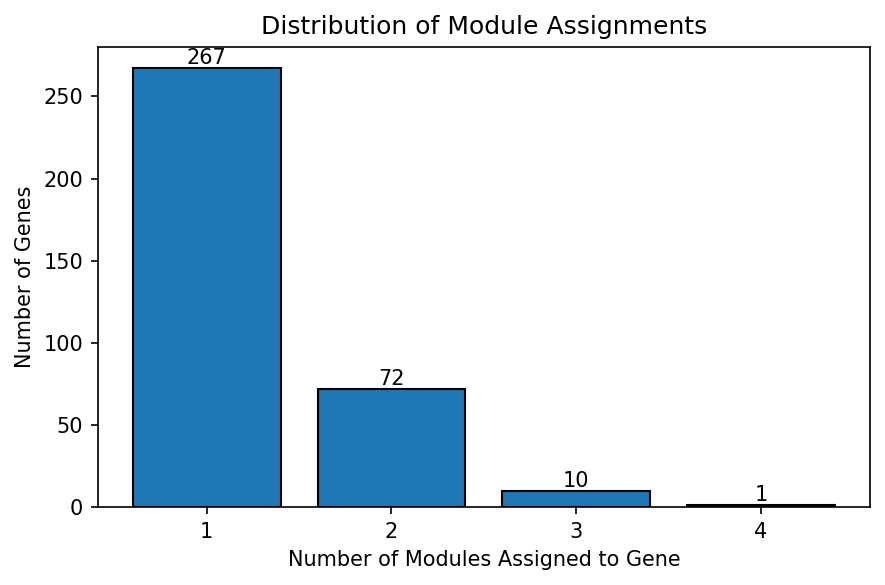

In [8]:
plot_module_distribution(module_assignments)

### Compute modPCA (and optionally UMAP)

In [9]:
umap(name=name, adata=adata, module_assignments=module_assignments, color=color,
     adata_path=adata_path, umap=False)   # set umap=True to also compute a UMAP on the modpcs 



/usersoftware/peerd/nandulaa/.conda/envs/vscode-base/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/usersoftware/peerd/nandulaa/.conda/envs/vscode-base/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/usersoftware/peerd/nandulaa/.conda/envs/vscode-base/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/usersoftware/peerd/nandulaa/.conda/envs/vscode-base/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata

pcs saved to anndata


In [12]:
adata.write(adata_path)